<a href="https://colab.research.google.com/github/Ganzadidier/Malaria-Diagnosis-CNN-Transfer-Learning/blob/Master/Advancedc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [ ]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

In [ ]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

## Populating namespaces

In [3]:
# Importing basic libraries
import os
import random
import shutil
from matplotlib import pyplot
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [5]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [4]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2025-10-03 21:39:10--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.167.192.111, 3.167.192.56, 3.167.192.32, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.167.192.111|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M  24.6MB/s    in 4.2s    

2025-10-03 21:39:15 (80.1 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

best_advanced_cnn.h5  cell_images  cell_images.zip  drive  sample_data


## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


In [5]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

data_dir = "/content/cell_images"
batch_size = 32
img_size = (128, 128)
seed = 123

# 1) Load full dataset WITHOUT shuffle (just to get class names)
full_ds_for_classes = image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)
class_names = full_ds_for_classes.class_names
print("Classes:", class_names)

# 2) Load full dataset WITH shuffle (for splitting)
full_ds = image_dataset_from_directory(
    data_dir,
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=seed
)

# Total number of images
num_samples = 27558  # you already printed this

# 3) Define split sizes
val_size = 0.15
test_size = 0.15
train_size = 1 - val_size - test_size

train_count = int(train_size * num_samples / batch_size)
val_count = int(val_size * num_samples / batch_size)

# 4) Split the dataset
train_ds = full_ds.take(train_count)
val_test_ds = full_ds.skip(train_count)
val_ds = val_test_ds.take(val_count)
test_ds = val_test_ds.skip(val_count)

# 5) Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


Found 27558 files belonging to 2 classes.
Classes: ['Parasitized', 'Uninfected']
Found 27558 files belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

...

602/602 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.9414 - loss: 0.1791 - val_accuracy: 0.9457 - val_loss: 0.1601
Epoch 5/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9454 - loss: 0.1571
Epoch 5: val_accuracy improved from 0.94574 to 0.94864, saving model to best_advanced_cnn_binary.h5


602/602 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.9454 - loss: 0.1571 - val_accuracy: 0.9486 - val_loss: 0.1378
Epoch 6/10
601/602 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9470 - loss: 0.1548
Epoch 6: val_accuracy improved from 0.94864 to 0.94961, saving model to best_advanced_cnn_binary.h5


602/602 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.9470 - loss: 0.1548 - val_accuracy: 0.9496 - val_loss: 0.1427
Epoch 7/10
601/602 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9480 - loss: 0.1551
Epoch 7: val_accuracy improved from 0.94961 to 0.95300, saving model to best_advanced_cnn_binary.h5


602/602 ━━━━━━━━━━━━━━━━━━━━ 43s 71ms/step - accuracy: 0.9480 - loss: 0.1551 - val_accuracy: 0.9530 - val_loss: 0.1431
Epoch 8/10
601/602 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9482 - loss: 0.1487
Epoch 8: val_accuracy did not improve from 0.95300
602/602 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.9481 - loss: 0.1487 - val_accuracy: 0.9513 - val_loss: 0.1475
Epoch 9/10
601/602 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.9525 - loss: 0.1471
Epoch 9: val_accuracy did not improve from 0.95300
602/602 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.9525 - loss: 0.1471 - val_accuracy: 0.9506 - val_loss: 0.1382
Epoch 10/10
602/602 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9516 - loss: 0.1497
Epoch 10: val_accuracy improved from 0.95300 to 0.95349, saving model to best_advanced_cnn_binary.h5


602/602 ━━━━━━━━━━━━━━━━━━━━ 42s 70ms/step - accuracy: 0.9516 - loss: 0.1497 - val_accuracy: 0.9535 - val_loss: 0.1426


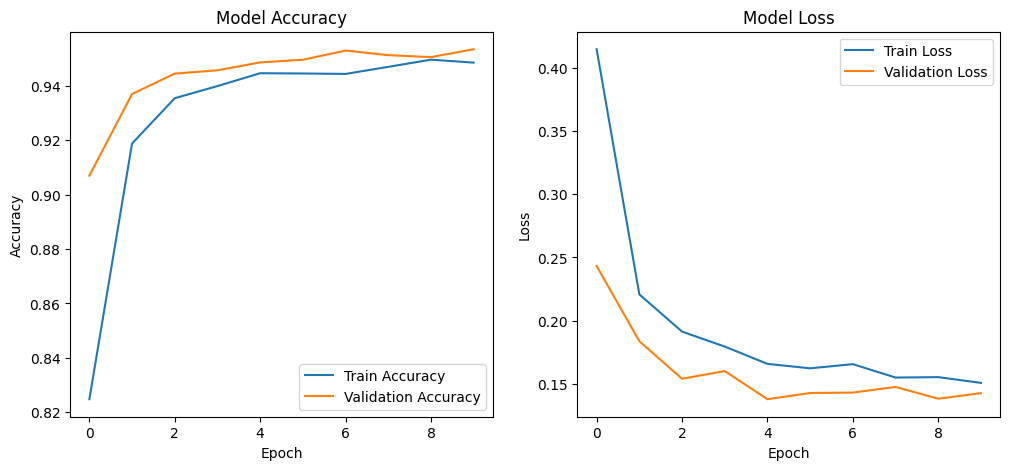

131/131 ━━━━━━━━━━━━━━━━━━━━ 19s 37ms/step
Classification Report:
              precision    recall  f1-score      support
Uninfected     0.501988  0.489341  0.495584  2064.000000
Parasitized    0.510678  0.523311  0.516917  2102.000000
accuracy       0.506481  0.506481  0.506481     0.506481
macro avg      0.506333  0.506326  0.506251  4166.000000
weighted avg   0.506373  0.506481  0.506348  4166.000000


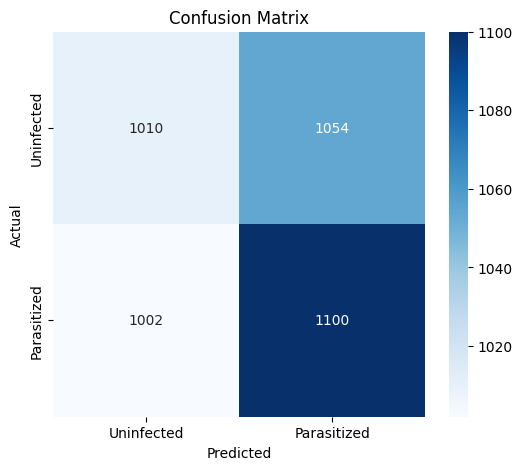

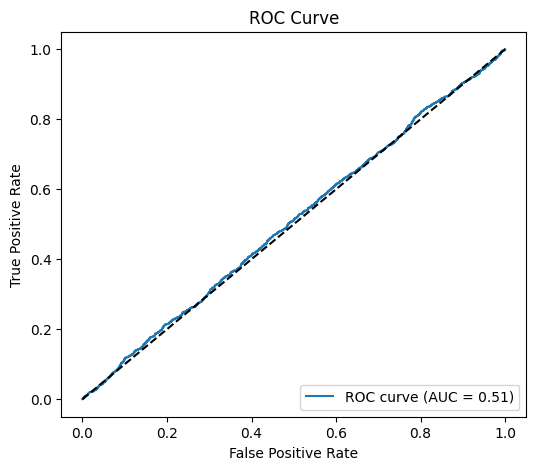

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

# -------------------------------
# 1️⃣ Data Augmentation
# -------------------------------
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

# -------------------------------
# 2️⃣ Build CNN Model (Binary)
# -------------------------------
def build_advanced_cnn_binary(input_shape=(128, 128, 3)):
    model = models.Sequential([
        data_augmentation,   # Apply augmentation

        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(256, (3, 3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')   # Binary output
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss='binary_crossentropy',              # Binary cross-entropy
        metrics=['accuracy']
    )
    return model

# -------------------------------
# 3️⃣ Build and Train the Model
# -------------------------------
advanced_cnn_binary = build_advanced_cnn_binary(input_shape=img_size + (3,))
advanced_cnn_binary.summary()

checkpoint = ModelCheckpoint(
    "best_advanced_cnn_binary.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

history_binary = advanced_cnn_binary.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint]
)

# -------------------------------
# 4️⃣ Plot Learning Curves
# -------------------------------
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_binary.history['accuracy'], label='Train Accuracy')
plt.plot(history_binary.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_binary.history['loss'], label='Train Loss')
plt.plot(history_binary.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# -------------------------------
# 5️⃣ Evaluate on Test Set
# -------------------------------
# True labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# Model predictions (probabilities)
y_pred_probs = advanced_cnn_binary.predict(test_ds)

# Convert probabilities to class labels
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# -------------------------------
# 6️⃣ Classification Report
# -------------------------------
class_names = ['Uninfected', 'Parasitized']  # Adjust if your classes are reversed
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
print("Classification Report:")
print(report_df)

# -------------------------------
# 7️⃣ Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# -------------------------------
# 8️⃣ ROC / AUC Curve
# -------------------------------
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC curve (AUC = %.2f)' % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


## Advanced CNN Experiment 2 (No Data Augmentation)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


602/602 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.6605 - loss: 0.8472 - val_accuracy: 0.8510 - val_loss: 0.3368
Epoch 2/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.8826 - loss: 0.2914 - val_accuracy: 0.9322 - val_loss: 0.2014
Epoch 3/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9307 - loss: 0.1988 - val_accuracy: 0.9331 - val_loss: 0.1890
Epoch 4/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 35s 58ms/step - accuracy: 0.9450 - loss: 0.1607 - val_accuracy: 0.9416 - val_loss: 0.1604
Epoch 5/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9514 - loss: 0.1304 - val_accuracy: 0.9494 - val_loss: 0.1702
Epoch 6/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9572 - loss: 0.1183 - val_accuracy: 0.9523 - val_loss: 0.1635
Epoch 7/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 28s 47ms/step - accuracy: 0.9630 - loss: 0.1000 - val_accuracy: 0.9489 - val_loss: 0.1742
Epoch 8/20
602/602 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9723 - loss: 0.0763 - val_accurac

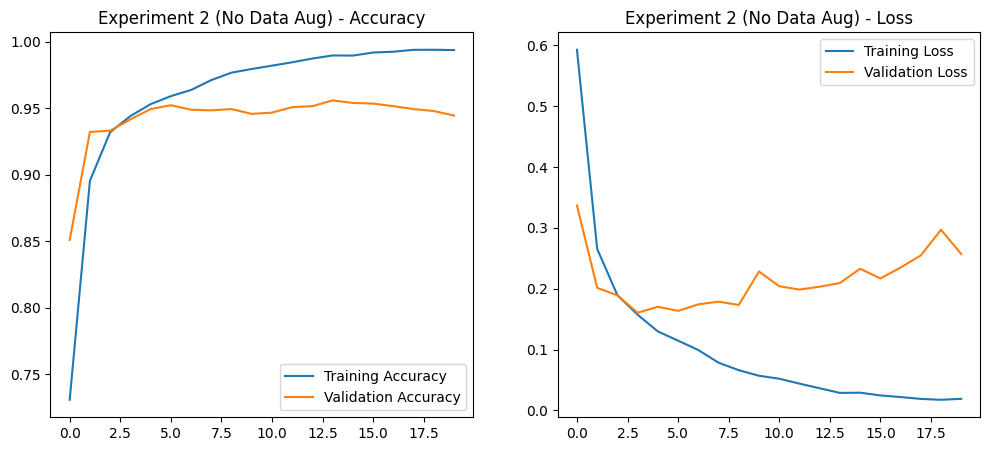

129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step


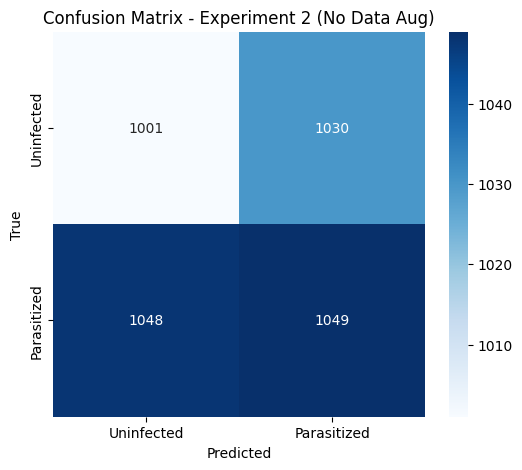

Classification Report:
               precision    recall  f1-score   support

  Uninfected       0.49      0.49      0.49      2031
 Parasitized       0.50      0.50      0.50      2097

    accuracy                           0.50      4128
   macro avg       0.50      0.50      0.50      4128
weighted avg       0.50      0.50      0.50      4128



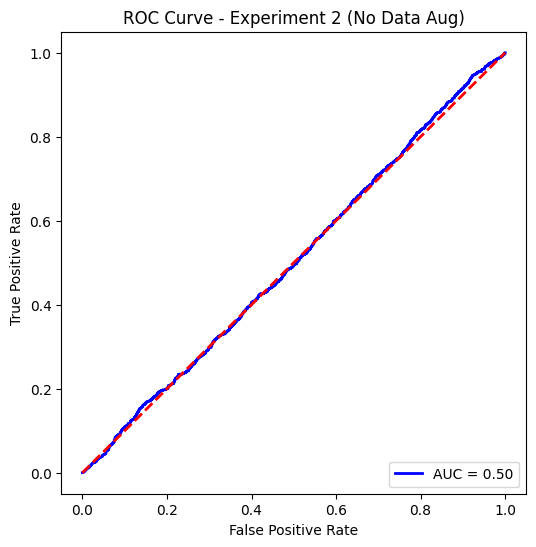

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns

# -------------------------------
# 1. Define Experiment 2 Model (No Data Aug)
# -------------------------------
def build_advanced_cnn_no_aug(input_shape=(128, 128, 3), num_classes=2):
    model = models.Sequential([
        # No augmentation here
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


# -------------------------------
# 2. Train Experiment 2 Model
# -------------------------------
advanced_cnn_no_aug = build_advanced_cnn_no_aug(input_shape=(128,128,3), num_classes=2)

history_no_aug = advanced_cnn_no_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)


# -------------------------------
# 3. Plot Learning Curves
# -------------------------------
def plot_learning_curves(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title(f'{title} - Accuracy')

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title(f'{title} - Loss')

    plt.show()

plot_learning_curves(history_no_aug, "Experiment 2 (No Data Aug)")

131/131 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step


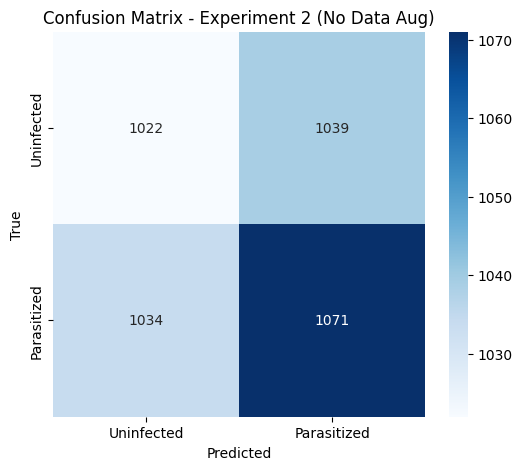

Classification Report:
               precision    recall  f1-score   support

  Uninfected       0.50      0.50      0.50      2061
 Parasitized       0.51      0.51      0.51      2105

    accuracy                           0.50      4166
   macro avg       0.50      0.50      0.50      4166
weighted avg       0.50      0.50      0.50      4166



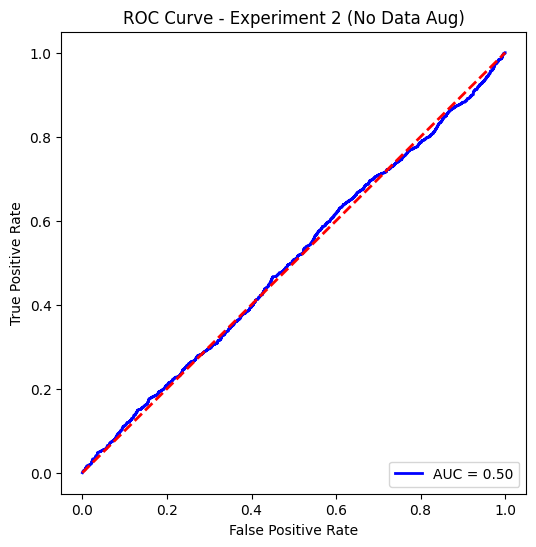

In [10]:
# -------------------------------
# 4. Confusion Matrix & Classification Report
# -------------------------------
# Extract true and predicted labels
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = advanced_cnn_no_aug.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Experiment 2 (No Data Aug)")
plt.show()

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", report)


# -------------------------------
# 5. ROC Curve & AUC
# -------------------------------
fpr, tpr, _ = roc_curve(y_true, y_pred_probs[:,1])  # probs for positive class
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], color='red', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Experiment 2 (No Data Aug)")
plt.legend(loc="lower right")
plt.show()
